# Stock-Trading Environment for RL with Risk-Adjusted Rewards and Technical Indicator

In [1]:
# Imports
import gymnasium
from gymnasium import spaces
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import ListedColormap
import matplotlib
import os


import random
from collections import namedtuple, deque
from itertools import count
import pickle
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torch.multiprocessing as mp


# Pre-processing the Historical Dataset

Used a kaggle data set link is below
https://www.kaggle.com/datasets/iveeaten3223times/massive-yahoo-finance-dataset


In [2]:
df = pd.read_csv('stock_details_5_years.csv')

# Columns for use to use from data set of columns
# Date Open High Low Close Volume Dividends Stock Splits Company
price_cols = ['Open', 'High', 'Low', 'Close']

# Convert date format to remove the time timestamp and handle errors
df['Date'] = pd.to_datetime(df['Date'], errors='coerce', utc=True)
df['Date'] = df['Date'].dt.date

# Filter for a Apple company stock
df = df[df['Company'] == 'AAPL'].sort_values('Date').reset_index(drop=True)
df = df.drop(columns=['Dividends', 'Stock Splits'])

# Feature engineering : technical indicators
# Moving averages
df['MA_20'] = df['Close'].rolling(window=20).mean()
df['MA_50'] = df['Close'].rolling(window=50).mean()

# Relative Strength Index
delta = df['Close'].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)
avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()
rs = avg_gain / avg_loss
df['RSI'] = 100 - (100 / (1 + rs))

# MACD
ema_12 = df['Close'].ewm(span=12, adjust=False).mean()
ema_26 = df['Close'].ewm(span=26, adjust=False).mean()
df['MACD'] = ema_12 - ema_26

# Support and resistance levels (last week of trading days)
df['Support'] = df['Low'].rolling(window=7).min()
df['Resistance'] = df['High'].rolling(window=7).max()

# Handle missing values
for col in price_cols + ['Volume']:
    if df[col].isna().any():
        df[col] = df[col].fillna(df[col].median())

df = df.dropna().reset_index(drop=True)
df = df.sort_values('Date').reset_index(drop=True)
df.to_csv('stock_details_5_years_processed.csv', index=False)

print(df.head())

         Date       Open       High        Low      Close    Volume Company  \
0  2019-02-12  40.991015  41.207897  40.894620  41.181389  89134000    AAPL   
1  2019-02-13  41.301874  41.564543  40.947630  41.010284  89960800    AAPL   
2  2019-02-14  40.897022  41.270540  40.817497  41.159691  87342800    AAPL   
3  2019-02-15  41.268142  41.376583  40.906669  41.068127  98507200    AAPL   
4  2019-02-19  40.897027  41.313924  40.844010  41.191021  75891200    AAPL   

       MA_20      MA_50        RSI      MACD    Support  Resistance  
0  39.005399  38.808659  75.383226  0.911749  40.139291   42.128498  
1  39.219435  38.767194  76.495284  0.903478  40.586161   42.128498  
2  39.418506  38.733373  73.010159  0.898620  40.586161   42.128498  
3  39.601961  38.667774  75.739389  0.877269  40.586161   41.737371  
4  39.780043  38.643650  80.610239  0.860347  40.586161   41.564543  


# Stock Trading Environment

In [2]:
class StockTradingEnv(gymnasium.Env):
    def __init__(self, file_path, train=True, window_size=50):
        super().__init__()
        self.data = pd.read_csv(file_path)
        self.window_size = window_size
        self.features = ['MA_20', 'MA_50', 'RSI', 'MACD', 'Support', 'Resistance']
        self.price_col = 'Close'

        # Split data into train/test
        split = int(0.8 * len(self.data))
        self.train = train
        self.market = self.data.iloc[:split].reset_index(drop=True) if train else self.data.iloc[split:].reset_index(drop=True)

        # Normalize features for better RL training
        for feature in self.features:
            if feature in self.market.columns:
                mean = self.market[feature].mean()
                std = self.market[feature].std()
                if std > 0:
                    self.market[feature] = (self.market[feature] - mean) / std

        # Spaces Initalisisation
        self.action_space = spaces.Discrete(3)
        obs_len = self.window_size * len(self.features) + 1 # window features + holding status
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(obs_len,), dtype=np.float32)

        self.max_steps = 150
        self.reset()

    def reset(self, seed=None, options=None):

        self.capital = 100_000
        self.num_shares = 0
        self.book_value = 0
        self.total_account_value = self.capital
        self.account_history = [self.capital]
        self.current_step = 0

        # Build observation with holding status
        window = self.market.iloc[self.current_step:self.current_step + self.window_size]

        obs = window[self.features].values.astype(np.float32)

        holding = np.array([1.0 if self.num_shares > 0 else 0.0], dtype=np.float32)

        obs = np.concatenate([obs.flatten(), holding])

        return obs, {}

    def step(self, action):
        price_idx = self.current_step + self.window_size
        price = self.data.iloc[price_idx][self.price_col] if self.train else \
                self.data.iloc[int(0.8 * len(self.data)) + price_idx][self.price_col]

        reward = 0.0
        invalid_action = False

        # Buy
        if action == 0:
            if self.capital >= price:
                shares_to_buy = int(self.capital // price)
                if shares_to_buy > 0:
                    self.num_shares += shares_to_buy
                    self.book_value += shares_to_buy * price
                    self.capital -= shares_to_buy * price
                else:
                    #capital < price
                    invalid_action = True
            else:
                invalid_action = True

        # Sell
        elif action == 1:
            if self.num_shares > 0:
                sell_value = self.num_shares * price
                profit = sell_value - self.book_value

                # Reward based on absolute profit
                reward += profit / 1000

                self.capital += sell_value
                self.book_value = 0
                self.num_shares = 0
            else:
                invalid_action = True

        # Action 2: Hold (nothing needed)

        # Penalty for invalid actions
        if invalid_action:
            reward -= 0.1

        # Update portfolio value
        self.total_account_value = self.capital + self.num_shares * price
        self.account_history.append(self.total_account_value)

        # Risk-adjusted reward (Sharpe-inspired)
        if len(self.account_history) > 10:
            recent_values = self.account_history[-11:]
            returns = np.diff(recent_values) / np.array(recent_values[:-1])
            volatility = np.std(returns)

            # Penalize excessive volatility
            reward -= volatility * 0.5

        self.current_step += 1
        terminated = self.current_step >= self.max_steps
        truncated = False

        info = {
            'total_value': self.total_account_value,
            'capital': self.capital,
            'shares': self.num_shares,
            'price': price
        }

        # Build observation with holding status
        window = self.market.iloc[self.current_step:self.current_step + self.window_size]

        obs = window[self.features].values.astype(np.float32)

        holding = np.array([1.0 if self.num_shares > 0 else 0.0], dtype=np.float32)

        obs = np.concatenate([obs.flatten(), holding])

        return obs, reward, terminated, truncated, info

    def render(self):
        plt.figure(figsize=(15, 6))
        plt.plot(self.account_history, color='blue', linewidth=2, label='Portfolio Value')
        plt.axhline(y=100000, color='red', linestyle='--', linewidth=1, label='Initial Capital')
        plt.xlabel("Time Step", fontsize=12)
        plt.ylabel("Total Account Value ($)", fontsize=12)
        plt.title("Portfolio Value Over Time", fontsize=14, fontweight='bold')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

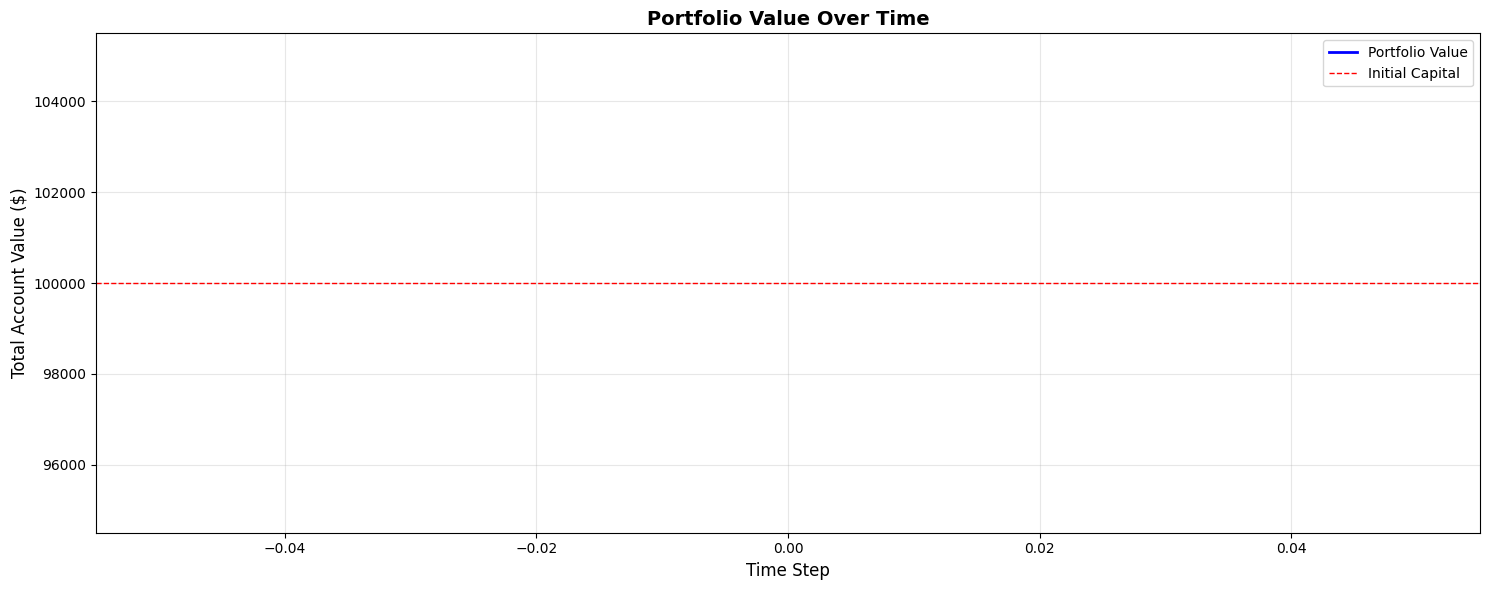

In [ ]:
env = StockTradingEnv('stock_details_5_years_processed.csv', train=True, window_size=50)

terminated, truncated = False, False
obs, info = env.reset()
env.render()

# Random

In [ ]:
class RandomAgent:
    def __init__(self, env):
        self.env = env
        self.observation_space = env.observation_space
        self.action_space = env.action_space

    def step(self, obs):
        """Takes a step in the environment by choosing an action randomly.
        Args:
            obs: The current observation.
        Returns:
            The action to take (0=Buy, 1=Sell, 2=Hold).
        """
        return np.random.choice(self.action_space.n)

Action: 2 , Reward: 0.0 , Done: False
Action: 1 , Reward: -0.1 , Done: False
Action: 1 , Reward: -0.1 , Done: False
Action: 2 , Reward: 0.0 , Done: False
Action: 1 , Reward: -0.1 , Done: False
Action: 1 , Reward: -0.1 , Done: False
Action: 1 , Reward: -0.1 , Done: False
Action: 2 , Reward: 0.0 , Done: False
Action: 0 , Reward: 0.0 , Done: False
Action: 2 , Reward: -2.953479766865348e-05 , Done: False
Action: 0 , Reward: -0.1016147031302241 , Done: False
Action: 1 , Reward: -0.026738017997830908 , Done: False
Action: 1 , Reward: -0.10248851371774188 , Done: False
Action: 0 , Reward: -0.002488513717741884 , Done: False
Action: 0 , Reward: -0.10329830637655994 , Done: False
Action: 0 , Reward: -0.10332278070253165 , Done: False
Action: 1 , Reward: -0.0016023421987998358 , Done: False
Action: 1 , Reward: -0.103359915135812 , Done: False
Action: 2 , Reward: -0.003359915135811991 , Done: False
Action: 1 , Reward: -0.10335645879007727 , Done: False
Action: 0 , Reward: -0.0030515433403582627 ,

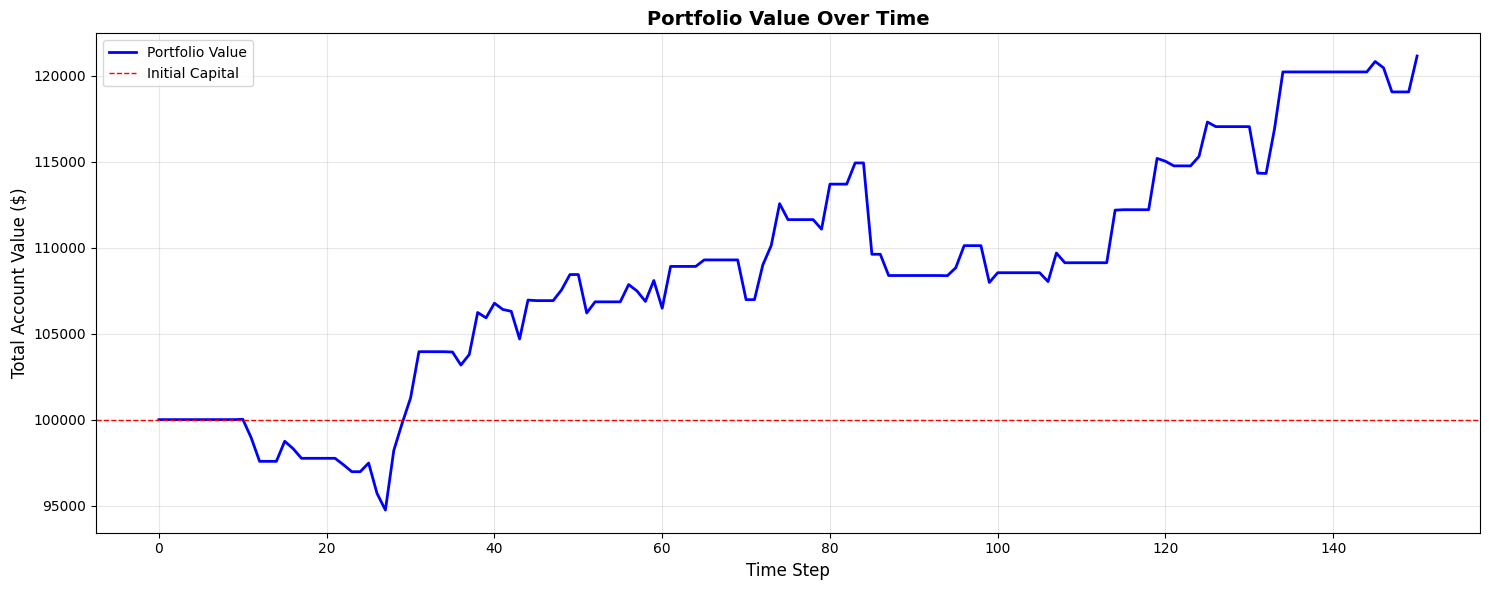

In [ ]:
if __name__ == '__main__':
    env = StockTradingEnv('stock_details_5_years_processed.csv', train=True, window_size=50)

    agent = RandomAgent(env)

    obs, info = env.reset()
    terminated, truncated = False, False

    while not terminated and not truncated:
        action = agent.step(obs)
        obs, reward, terminated, truncated, info = env.step(action)
        print('Action:', action, ', Reward:', reward, ', Done:', terminated)

    env.render()



#DQN and training

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

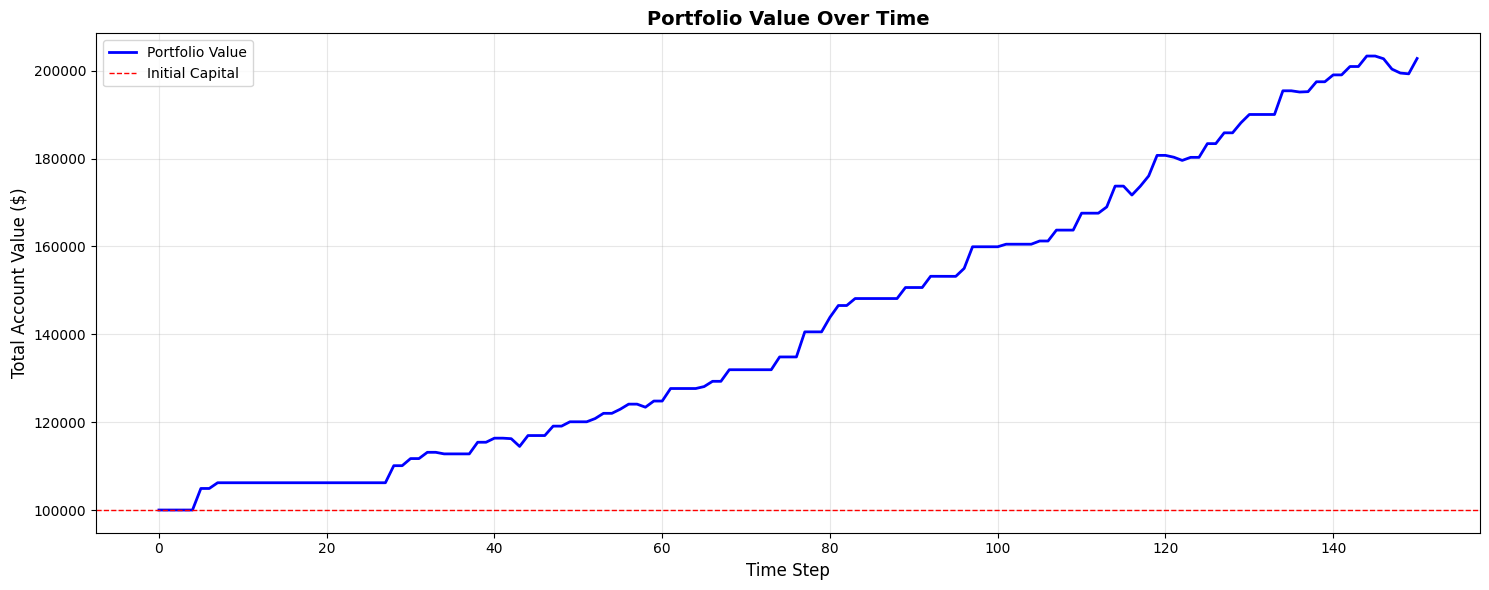

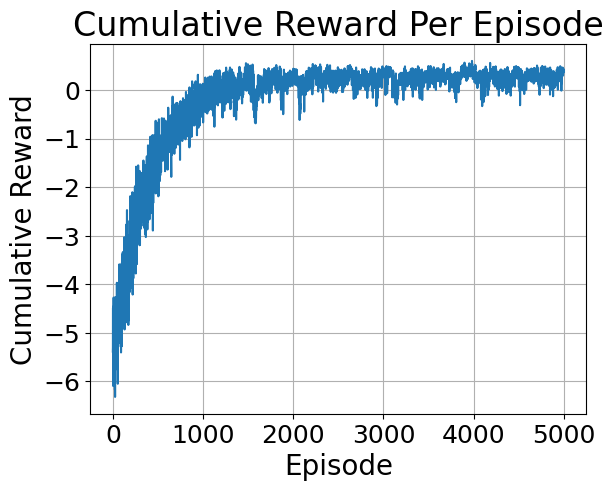

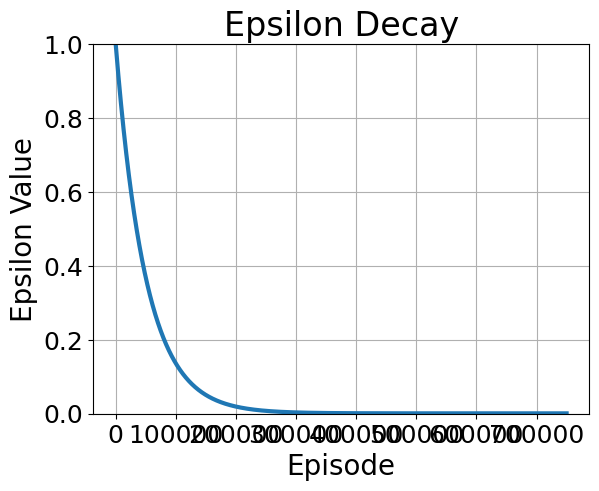

In [ ]:
#stockmarket environment
def obs_tuple(obs):
    return torch.tensor(obs, dtype=torch.float32).reshape(1, -1).to(device)

# DQN learning function with all parameters specified at the top
def DQN_stockmarket_learning(memory_size=10000, env= StockTradingEnv('stock_details_5_years_processed.csv', train=True, window_size=50), obs_tuple=obs_tuple,
                 hidden_layer=64, batch_size=128, gamma=0.99,
                 c=10, epsilon_start=1.0, epsilon_min=0.001, epsilon_decay=50000,
                 optimize_time=5, episodes=5000):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # to keep track of transitions
    Transition = namedtuple('Transition', ('state', 'action', 'next_state', 'reward'))

    # Initialising Replay Memory
    class ReplayMemory(object):
        def __init__(self, capacity):
            self.memory = deque([], maxlen=capacity)

        def push(self, *args):
            self.memory.append(Transition(*args))

        def sample(self, batch_size):
            return random.sample(self.memory, batch_size)

        def __len__(self):
            return len(self.memory)

    # the Network
    class DQN(nn.Module):
        def __init__(self, num_obs, n_act):
            super().__init__()
            self.fc1 = nn.Linear(num_obs, hidden_layer)
            self.fc2 = nn.Linear(hidden_layer, hidden_layer)
            self.fc3 = nn.Linear(hidden_layer, n_act)

        def forward(self, x):
            x = F.relu(self.fc1(x))
            x = F.relu(self.fc2(x))
            return self.fc3(x)

    # initialising all the action states and policy nets
    num_obs = env.observation_space.shape[0]
    n_actions = env.action_space.n
    state, info = env.reset()

    policy_net = DQN(num_obs, n_actions).to(device)
    target_net = DQN(num_obs, n_actions).to(device)
    target_net.load_state_dict(policy_net.state_dict())

    # optimiser used in accordance to DeepMind’s initial paper
    optimizer = optim.AdamW(policy_net.parameters(), lr=0.00025)
    memory = ReplayMemory(memory_size)

    rewards_per_episode = []
    epsilons = []
    step = 0

    for ep in range(episodes):
        obs, info = env.reset()
        state = obs_tuple(obs)
        total_reward = 0.0
        done = False  # flag to check when completed

        while not done:
            step += 1
            # greedy action with linear epsilon decay
            # epsilon = max(epsilon_min, epsilon_start * (epsilon_decay ** ep))
            epsilon = epsilon_min + (epsilon_start - epsilon_min) * math.exp(-1. * step / epsilon_decay)

            epsilons.append(epsilon)

            if np.random.rand() > epsilon:
                with torch.no_grad():
                    action = policy_net(state).max(1).indices.view(1, 1)
            else:
                action = torch.tensor([[env.action_space.sample()]], device=device, dtype=torch.long)

            obs, reward, terminated, truncated, _ = env.step(action.item())
            done = terminated or truncated
            total_reward += reward

            reward_t = torch.tensor([reward], device=device)
            next_state = None if done else obs_tuple(obs)

            memory.push(state, action, next_state, reward_t)
            state = next_state

            if step % optimize_time == 0:
                if len(memory) < batch_size:
                    continue

                transitions = memory.sample(batch_size)
                batch = Transition(*zip(*transitions))

                mask = torch.tensor([s is not None for s in batch.next_state],
                                    device=device, dtype=torch.bool)
                notfinal_nextstate = torch.cat([s for s in batch.next_state if s is not None]).to(device)
                sbatch = torch.cat(batch.state).to(device)
                a_batch = torch.cat(batch.action).to(device)
                rbatch = torch.cat(batch.reward).to(device).to(torch.float32)

                state_action_values = policy_net(sbatch).gather(1, a_batch)
                next_sv = torch.zeros(batch_size, device=device)

                with torch.no_grad():
                    if len(notfinal_nextstate) > 0:
                        next_sv[mask] = target_net(notfinal_nextstate).max(1).values

                expected = (next_sv * gamma) + rbatch
                criterion = nn.MSELoss()
                loss = criterion(state_action_values, expected.reshape(-1, 1))

                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_value_(policy_net.parameters(), 100)
                optimizer.step()

            if ep % c == 0:
                target_net.load_state_dict(policy_net.state_dict())

        rewards_per_episode.append(total_reward)
    env.render()

    #model saved
    torch.save(policy_net.state_dict(), 'dqn_stock_market_weights.pth')

    # Cumulative reward per episode
    plt.figure()
    plt.plot(rewards_per_episode)
    plt.xlabel('Episode', fontsize=20)
    plt.ylabel('Cumulative Reward', fontsize=20)
    plt.title('Cumulative Reward Per Episode', fontsize=24)
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    plt.grid()
    plt.show()

    # Epsilon decay
    plt.figure()
    plt.plot(epsilons, linewidth=3)
    plt.xlabel('Episode', fontsize=20)
    plt.ylabel('Epsilon Value', fontsize=20)
    plt.title('Epsilon Decay', fontsize=24)
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    plt.ylim(ymin=0, ymax=1)
    plt.grid()
    plt.show()

DQN_stockmarket_learning()

# Backtesting agent


In [ ]:
class DQNBacktestAgent:
    def __init__(self, env, model_path, hidden_layer=64):
        """Load trained DQN policy for backtesting"""
        self.env = env
        num_obs = env.observation_space.shape[0]
        n_actions = env.action_space.n

        class DQN(nn.Module):
            def __init__(self, num_obs, n_act):
                super().__init__()
                self.fc1 = nn.Linear(num_obs, hidden_layer)
                self.fc2 = nn.Linear(hidden_layer, hidden_layer)
                self.fc3 = nn.Linear(hidden_layer, n_act)

            def forward(self, x):
                x = F.relu(self.fc1(x))
                x = F.relu(self.fc2(x))
                return self.fc3(x)

        # Initialize and load trained weights
        self.policy_net = DQN(num_obs, n_actions).to(device)
        self.policy_net.load_state_dict(torch.load(model_path, map_location=device))
        self.policy_net.eval()

    def step(self, obs):
        """Select action using trained policy (greedy, no exploration)
        Args:
            obs: The current observation
        Returns:
            The action to take (0=Buy, 1=Sell, 2=Hold)
        """
        state = torch.tensor(obs, dtype=torch.float32).reshape(1, -1).to(device)
        # Get greedy action
        with torch.no_grad():
            action = self.policy_net(state).max(1).indices.item()

        return action

Action: 0 , Reward: 0.0 , Done: False
Action: 0 , Reward: -0.1 , Done: False
Action: 0 , Reward: -0.1 , Done: False
Action: 0 , Reward: -0.1 , Done: False
Action: 0 , Reward: -0.1 , Done: False
Action: 2 , Reward: 0.0 , Done: False
Action: 2 , Reward: 0.0 , Done: False
Action: 2 , Reward: 0.0 , Done: False
Action: 1 , Reward: 0.018029548645024915 , Done: False
Action: 0 , Reward: -0.007530333327543605 , Done: False
Action: 1 , Reward: 0.005791559824349747 , Done: False
Action: 2 , Reward: -0.007649831629455022 , Done: False
Action: 2 , Reward: -0.007100067146747307 , Done: False
Action: 2 , Reward: -0.007139540834137295 , Done: False
Action: 0 , Reward: -0.0050219824015716825 , Done: False
Action: 1 , Reward: 0.011194640924885816 , Done: False
Action: 0 , Reward: -0.004056092714345956 , Done: False
Action: 1 , Reward: -0.013767826878188463 , Done: False
Action: 1 , Reward: -0.1033898692516867 , Done: False
Action: 1 , Reward: -0.1033898692516867 , Done: False
Action: 1 , Reward: -0.102

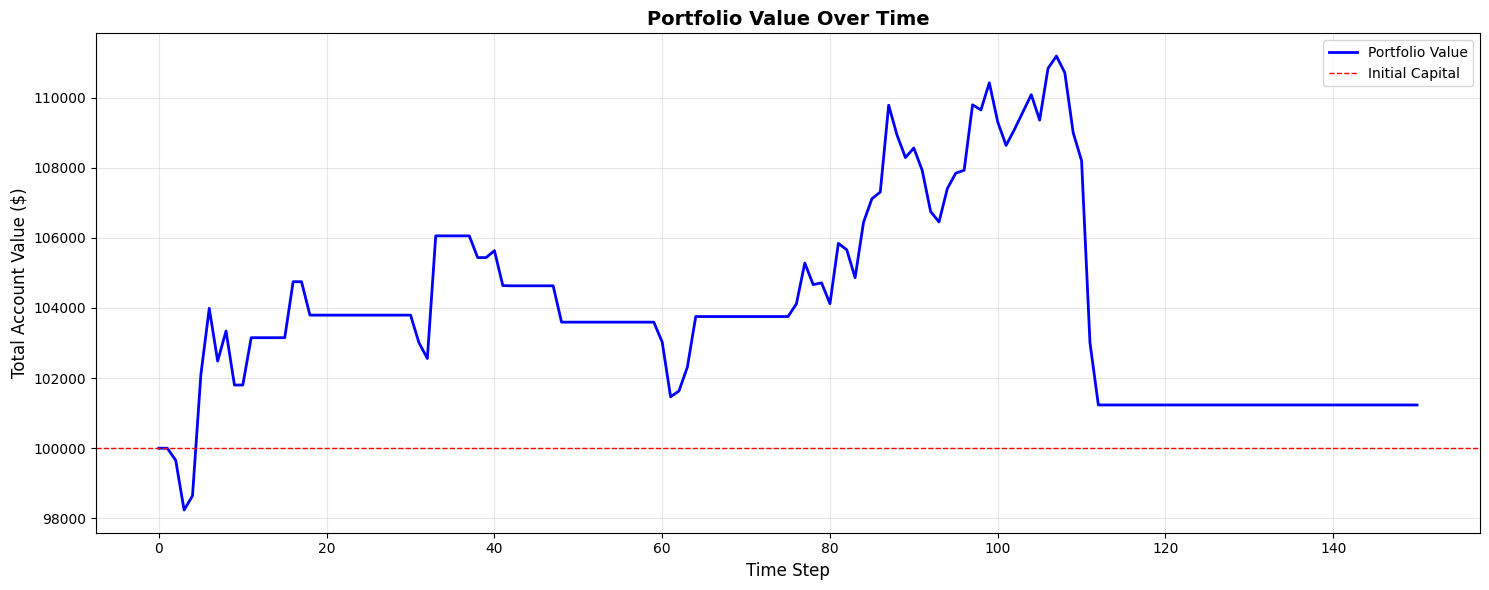

In [ ]:
if __name__ == '__main__':
    env = StockTradingEnv('stock_details_5_years_processed.csv', train=False, window_size=50)
    agent = DQNBacktestAgent(env, 'dqn_stock_market_weights.pth', hidden_layer=64)

    obs, info = env.reset()
    terminated, truncated = False, False
    step_count = 0
    total_reward = 0.0
    while not terminated and not truncated:
        action = agent.step(obs)
        obs, reward, terminated, truncated, info = env.step(action)
        print('Action:', action, ', Reward:', reward, ', Done:', terminated)

    env.render()

#DDQN and training

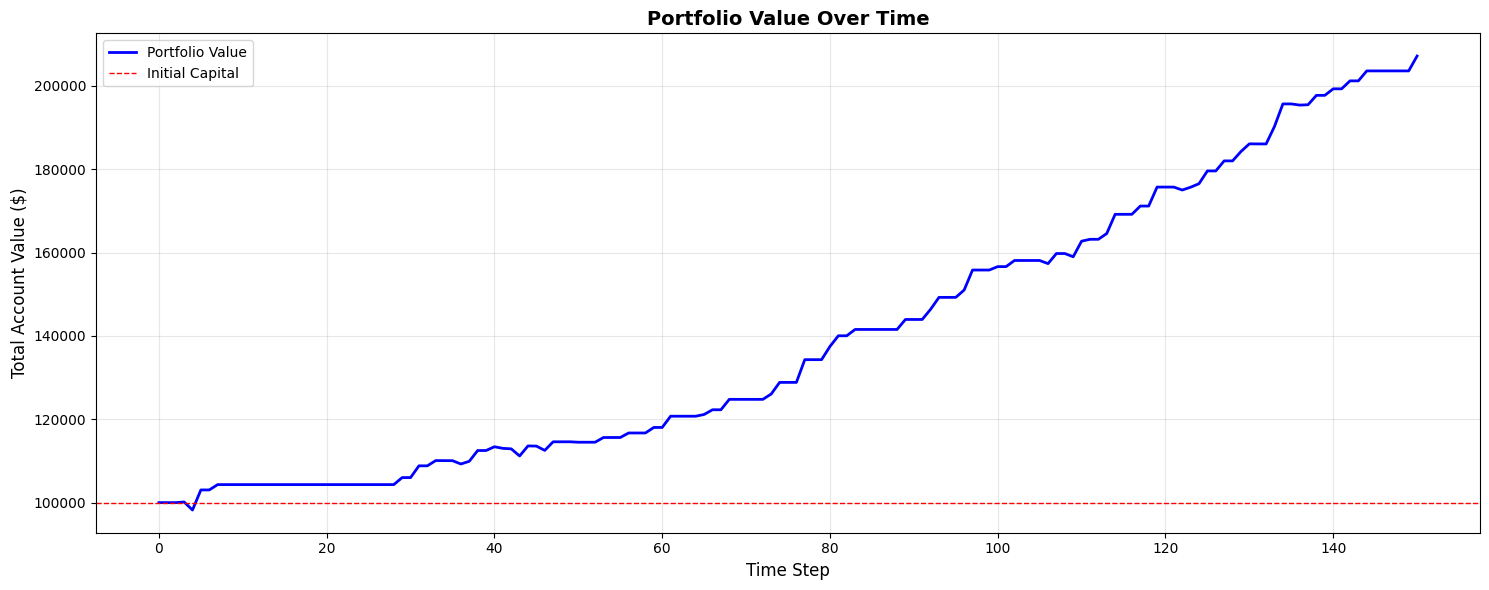

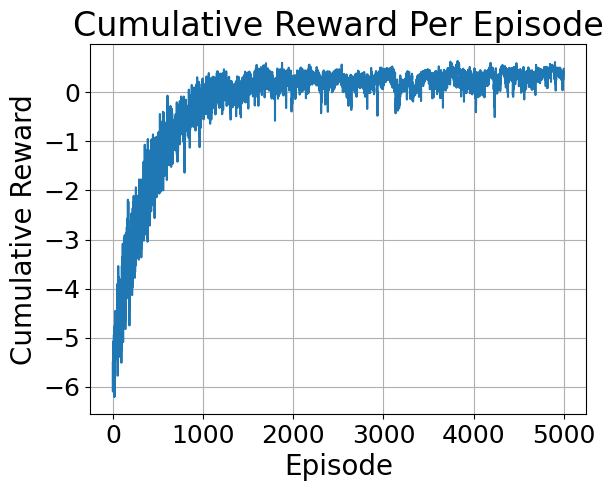

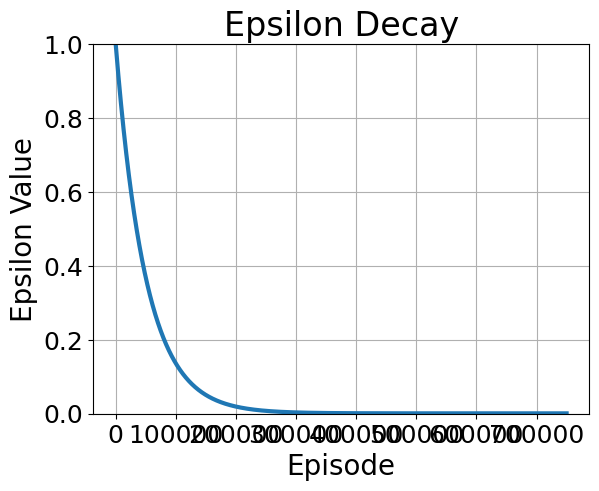

In [ ]:
#stockmarket environment
def obs_tuple(obs):
    return torch.tensor(obs, dtype=torch.float32).reshape(1, -1).to(device)

# DQN learning function with all parameters specified at the top
def Double_DQN_stockmarket_learning(memory_size=10000, env= StockTradingEnv('stock_details_5_years_processed.csv', train=True, window_size=50), obs_tuple=obs_tuple,
                 hidden_layer=64, batch_size=128, gamma=0.99,
                 c=10, epsilon_start=1.0, epsilon_min=0.001, epsilon_decay=50000,
                 optimize_time=5, episodes=5000):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # to keep track of transitions
    Transition = namedtuple('Transition', ('state', 'action', 'next_state', 'reward'))

    # Initialising Replay Memory
    class ReplayMemory(object):
        def __init__(self, capacity):
            self.memory = deque([], maxlen=capacity)

        def push(self, *args):
            self.memory.append(Transition(*args))

        def sample(self, batch_size):
            return random.sample(self.memory, batch_size)

        def __len__(self):
            return len(self.memory)

    # the Network
    class DQN(nn.Module):
        def __init__(self, num_obs, n_act):
            super().__init__()
            self.fc1 = nn.Linear(num_obs, hidden_layer)
            self.fc2 = nn.Linear(hidden_layer, hidden_layer)
            self.fc3 = nn.Linear(hidden_layer, n_act)

        def forward(self, x):
            x = F.relu(self.fc1(x))
            x = F.relu(self.fc2(x))
            return self.fc3(x)

    # initialising all the action states and policy nets
    num_obs = env.observation_space.shape[0]
    n_actions = env.action_space.n
    state, info = env.reset()

    policy_net = DQN(num_obs, n_actions).to(device)
    target_net = DQN(num_obs, n_actions).to(device)
    target_net.load_state_dict(policy_net.state_dict())

    # optimiser used in accordance to DeepMind’s initial paper
    optimizer = optim.AdamW(policy_net.parameters(), lr=0.00025)
    memory = ReplayMemory(memory_size)

    rewards_per_episode = []
    epsilons = []
    step = 0

    for ep in range(episodes):
        obs, info = env.reset()
        state = obs_tuple(obs)
        total_reward = 0.0
        done = False  # flag to check when completed

        while not done:
            step += 1
            # greedy action with linear epsilon decay
            # epsilon = max(epsilon_min, epsilon_start * (epsilon_decay ** ep))
            epsilon = epsilon_min + (epsilon_start - epsilon_min) * math.exp(-1. * step / epsilon_decay)

            epsilons.append(epsilon)

            if np.random.rand() > epsilon:
                with torch.no_grad():
                    action = policy_net(state).max(1).indices.view(1, 1)
            else:
                action = torch.tensor([[env.action_space.sample()]], device=device, dtype=torch.long)

            obs, reward, terminated, truncated, _ = env.step(action.item())
            done = terminated or truncated
            total_reward += reward

            reward_t = torch.tensor([reward], device=device)
            next_state = None if done else obs_tuple(obs)

            memory.push(state, action, next_state, reward_t)
            state = next_state

            if step % optimize_time == 0:
                if len(memory) < batch_size:
                    continue

                transitions = memory.sample(batch_size)
                batch = Transition(*zip(*transitions))

                mask = torch.tensor([s is not None for s in batch.next_state],
                                    device=device, dtype=torch.bool)
                notfinal_nextstate = torch.cat([s for s in batch.next_state if s is not None]).to(device)
                sbatch = torch.cat(batch.state).to(device)
                a_batch = torch.cat(batch.action).to(device)
                rbatch = torch.cat(batch.reward).to(device).to(torch.float32)

                state_action_values = policy_net(sbatch).gather(1, a_batch)
                next_sv = torch.zeros(batch_size, device=device)

                with torch.no_grad():
                    if len(notfinal_nextstate) > 0: # finding the best action (qvalue) using the greedy approach
                        greedy_action = policy_net(notfinal_nextstate).max(1).indices.view(-1, 1)
                        next_sv[mask] = target_net(notfinal_nextstate).gather(1, greedy_action).view(-1)


                expected = (next_sv * gamma) + rbatch
                criterion = nn.MSELoss()
                loss = criterion(state_action_values, expected.reshape(-1, 1))

                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_value_(policy_net.parameters(), 100)
                optimizer.step()

            if ep % c == 0:
                target_net.load_state_dict(policy_net.state_dict())

        rewards_per_episode.append(total_reward)
    env.render()

    #model saved
    torch.save(policy_net.state_dict(), 'double_dqn_stock_market_weights.pth')

    # Cumulative reward per episode
    plt.figure()
    plt.plot(rewards_per_episode)
    plt.xlabel('Episode', fontsize=20)
    plt.ylabel('Cumulative Reward', fontsize=20)
    plt.title('Cumulative Reward Per Episode', fontsize=24)
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    plt.grid()
    plt.show()

    # Epsilon decay
    plt.figure()
    plt.plot(epsilons, linewidth=3)
    plt.xlabel('Episode', fontsize=20)
    plt.ylabel('Epsilon Value', fontsize=20)
    plt.title('Epsilon Decay', fontsize=24)
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    plt.ylim(ymin=0, ymax=1)
    plt.grid()
    plt.show()

Double_DQN_stockmarket_learning()

#Backtesting DDQN

Action: 0 , Reward: 0.0 , Done: False
Action: 1 , Reward: -0.003443796386715403 , Done: False
Action: 1 , Reward: -0.1 , Done: False
Action: 0 , Reward: 0.0 , Done: False
Action: 1 , Reward: 0.034930233764650036 , Done: False
Action: 1 , Reward: -0.1 , Done: False
Action: 0 , Reward: 0.0 , Done: False
Action: 1 , Reward: 0.008639007873536029 , Done: False
Action: 1 , Reward: -0.1 , Done: False
Action: 1 , Reward: -0.10536356766383062 , Done: False
Action: 1 , Reward: -0.10536356766383062 , Done: False
Action: 1 , Reward: -0.1052681361419349 , Done: False
Action: 1 , Reward: -0.1052681361419349 , Done: False
Action: 1 , Reward: -0.1052681361419349 , Done: False
Action: 1 , Reward: -0.10125629492940741 , Done: False
Action: 1 , Reward: -0.10125629492940741 , Done: False
Action: 1 , Reward: -0.10125629492940741 , Done: False
Action: 1 , Reward: -0.1 , Done: False
Action: 1 , Reward: -0.1 , Done: False
Action: 1 , Reward: -0.1 , Done: False
Action: 1 , Reward: -0.1 , Done: False
Action: 1 

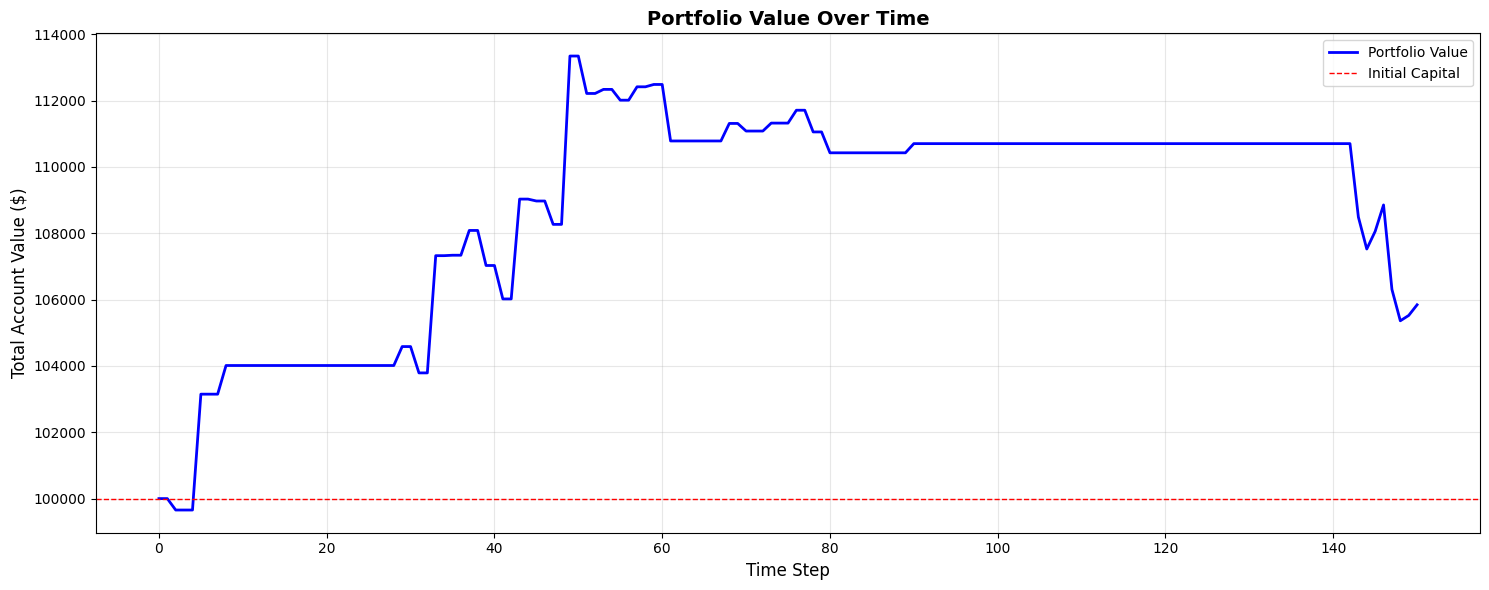

In [ ]:
if __name__ == '__main__':
    env = StockTradingEnv('stock_details_5_years_processed.csv', train=False, window_size=50)
    agent = DQNBacktestAgent(env, 'double_dqn_stock_market_weights.pth', hidden_layer=64)

    obs, info = env.reset()
    terminated, truncated = False, False
    step_count = 0
    total_reward = 0.0
    while not terminated and not truncated:
        action = agent.step(obs)
        obs, reward, terminated, truncated, info = env.step(action)
        print('Action:', action, ', Reward:', reward, ', Done:', terminated)

    env.render()

#A2C and training

In [11]:
def A2C_StockTrading(env_fn, hidden_size=256, n_episodes=200,
                     gamma=0.99, lr=1e-4, file_name=None):

    class ActorCritic(nn.Module):
        def __init__(self, obs_dim, act_dim, h):
            super().__init__()
            self.fc1 = nn.Linear(obs_dim, h)
            self.fc2 = nn.Linear(h, h)
            self.actor = nn.Linear(h, act_dim)
            self.critic = nn.Linear(h, 1)

        def forward(self, x):
            x = F.relu(self.fc1(x))
            x = F.relu(self.fc2(x))
            probs = F.softmax(self.actor(x), dim=-1)
            value = self.critic(x)
            return probs, value

    env = env_fn
    obs_dim = env.observation_space.shape[0]
    act_dim = env.action_space.n

    model = ActorCritic(obs_dim, act_dim, hidden_size)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    all_rewards = []

    #main training loop
    for ep in range(n_episodes):
        obs, _ = env.reset()
        done = False

        states, actions, rewards, values = [], [], [], []
        total_reward = 0

        while not done:
            s = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)
            probs, value = model(s)

            dist = probs.squeeze(0)
            action = torch.multinomial(dist, 1).item()

            next_obs, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            states.append(s)
            actions.append(action)
            rewards.append(reward)
            values.append(value.item())

            total_reward += reward
            obs = next_obs

        # Compute returns
        R = 0
        returns = []
        for r in reversed(rewards):
            R = r + gamma * R
            returns.insert(0, R)

        returns = torch.tensor(returns, dtype=torch.float32)
        values = torch.tensor(values, dtype=torch.float32)
        advantages = returns - values

        policy_losses = []
        value_losses = []
        entropies = []

        for s, a, adv, ret in zip(states, actions, advantages, returns):
            probs, value = model(s)
            logp = torch.log(probs.squeeze()[a] + 1e-8)
            entropy = -(probs * torch.log(probs + 1e-8)).sum()

            policy_losses.append(-logp * adv.detach())
            value_losses.append((ret - value.squeeze()) ** 2)
            entropies.append(-0.01 * entropy)

        loss = (
            torch.stack(policy_losses).sum()
            + torch.stack(value_losses).sum()
            + torch.stack(entropies).sum()
        )

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
        optimizer.step()

        all_rewards.append(total_reward)
        if file_name:
            torch.save(model.state_dict(), file_name)

    env.render()

    env = env_fn
    obs, _ = env.reset()
    done = False

    while not done:
        s = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)
        with torch.no_grad():
            probs, _ = model(s)
        action = torch.argmax(probs, dim=-1).item()

        obs, _, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

    env.render()
    env.close()

    return np.array(all_rewards)


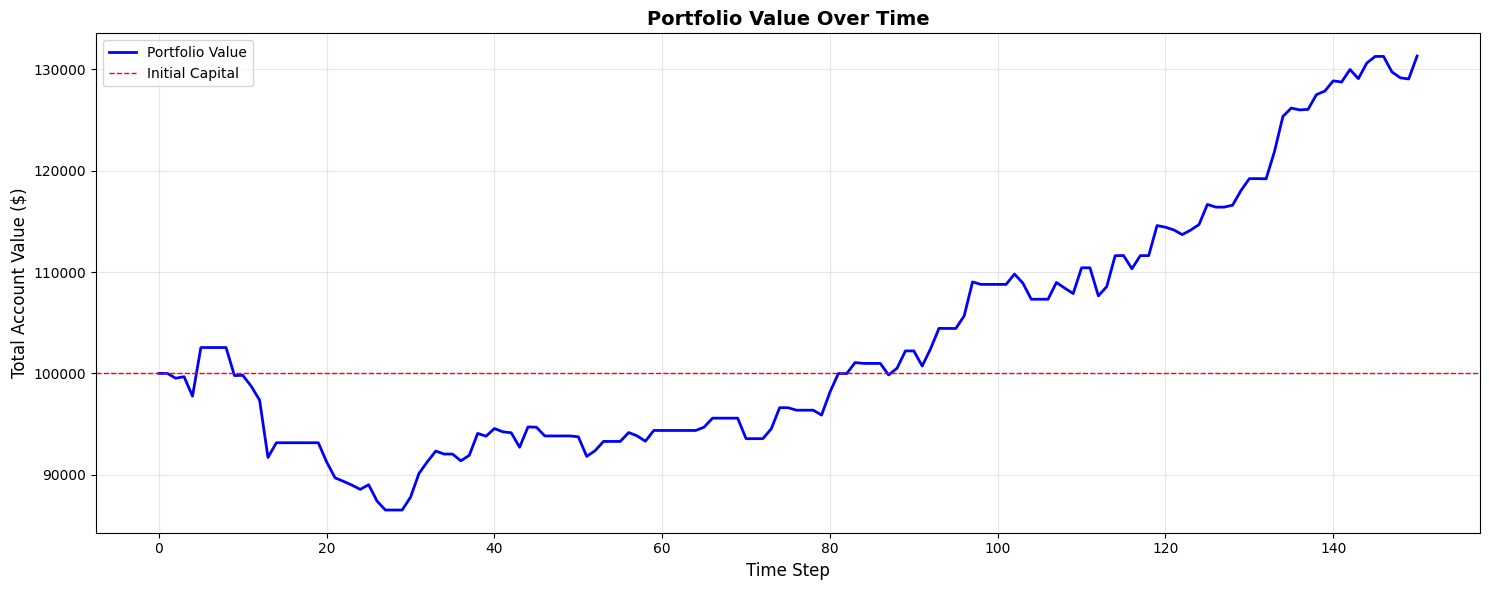

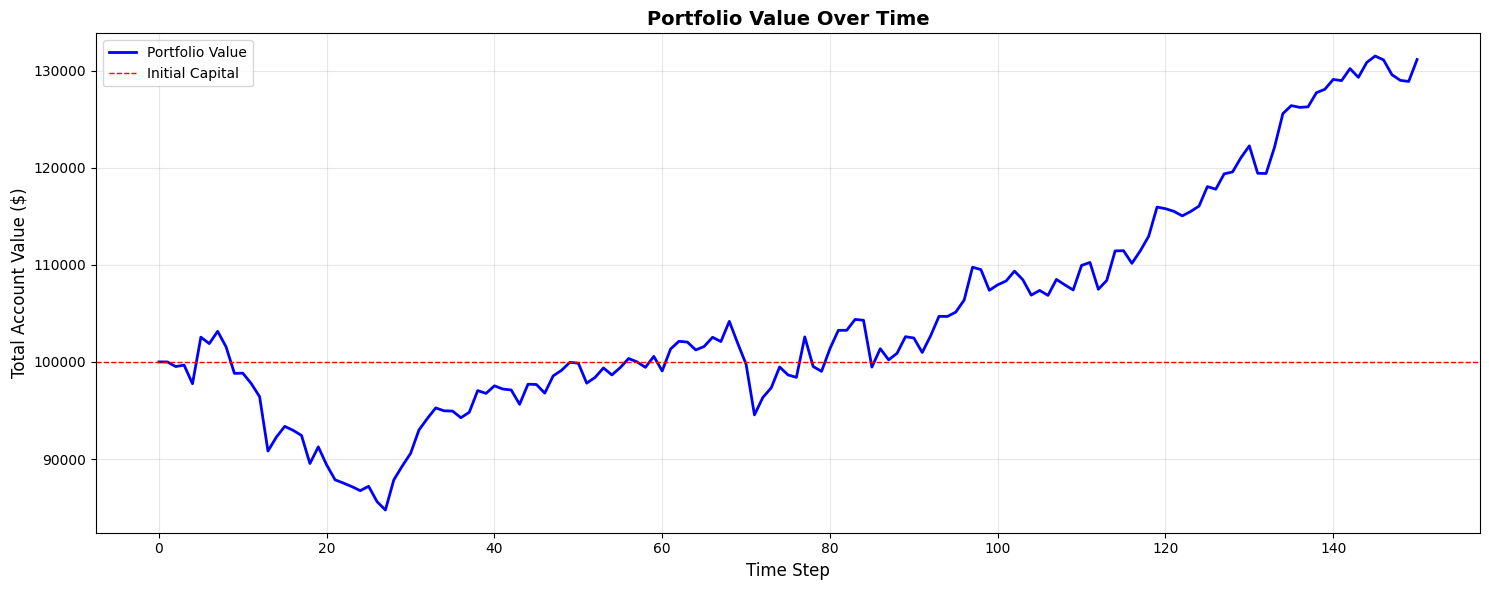

In [17]:
env = StockTradingEnv(file_path="stock_details_5_years_processed.csv",train=True,window_size=50)

rewards = A2C_StockTrading(env_fn=env, hidden_size=256,n_episodes=300,gamma=0.99,lr=1e-4, file_name="a2c_stock.pth")


#Backtesting A2C

In [29]:
class A2CBacktestAgent:
    def __init__(self, env, model_path, hidden_size=256, greedy=True):
        self.env = env
        self.greedy = greedy
        obs_dim = env.observation_space.shape[0]
        act_dim = env.action_space.n

        class ActorCritic(nn.Module):
            def __init__(self, obs_dim, act_dim, hidden_size):
                super().__init__()
                self.fc1 = nn.Linear(obs_dim, hidden_size)
                self.fc2 = nn.Linear(hidden_size, hidden_size)
                self.actor = nn.Linear(hidden_size, act_dim)
                self.critic = nn.Linear(hidden_size, 1)

            def forward(self, x):
                x = F.relu(self.fc1(x))
                x = F.relu(self.fc2(x))
                probs = F.softmax(self.actor(x), dim=-1)
                value = self.critic(x)
                return probs, value

        self.policy_net = ActorCritic(obs_dim, act_dim, hidden_size)
        self.policy_net.load_state_dict(torch.load(model_path, map_location="cpu"))
        self.policy_net.eval()

    def step(self, obs):
        state = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)
        with torch.no_grad():
            probs, _ = self.policy_net(state)
            if self.greedy:
                action = torch.argmax(probs, dim=-1).item()
            else:
                dist = torch.distributions.Categorical(probs)
                action = dist.sample().item()
        return action


Action: 2 Reward: 0.0 Value: 100000.0
Action: 2 Reward: 0.0 Value: 100000.0
Action: 2 Reward: 0.0 Value: 100000.0
Action: 2 Reward: 0.0 Value: 100000.0
Action: 2 Reward: 0.0 Value: 100000.0
Action: 2 Reward: 0.0 Value: 100000.0
Action: 2 Reward: 0.0 Value: 100000.0
Action: 2 Reward: 0.0 Value: 100000.0
Action: 2 Reward: 0.0 Value: 100000.0
Action: 2 Reward: 0.0 Value: 100000.0
Action: 2 Reward: 0.0 Value: 100000.0
Action: 2 Reward: 0.0 Value: 100000.0
Action: 2 Reward: 0.0 Value: 100000.0
Action: 2 Reward: 0.0 Value: 100000.0
Action: 0 Reward: 0.0 Value: 100000.0
Action: 2 Reward: -0.002319790580749817 Value: 101546.52705383321
Action: 0 Reward: -0.1027678908751467 Value: 102757.97373962398
Action: 0 Reward: -0.10328130934865574 Value: 101823.6167297364
Action: 0 Reward: -0.10334966901373441 Value: 102532.43792724593
Action: 0 Reward: -0.10342356943889439 Value: 103383.02731323235
Action: 0 Reward: -0.10414410497592874 Value: 102113.58993530297
Action: 0 Reward: -0.10423700917860748 Va

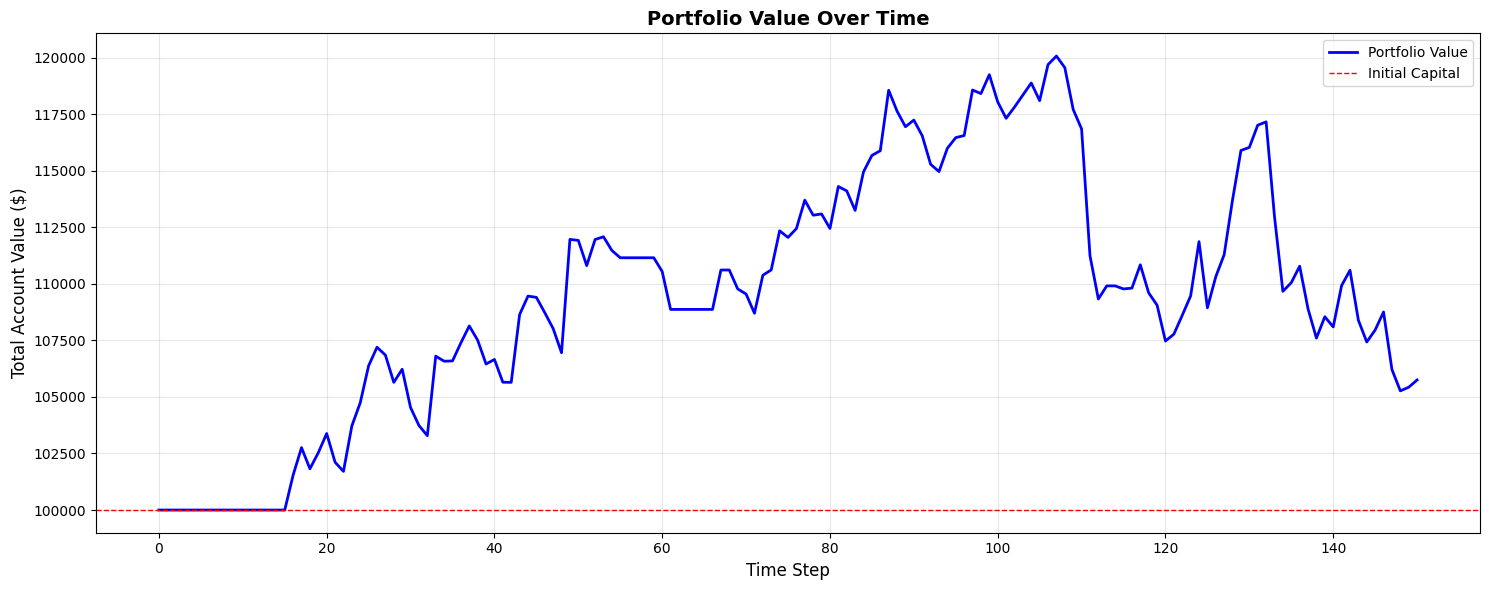

In [31]:
env_test = StockTradingEnv(file_path="stock_details_5_years_processed.csv",train=False,window_size=50)
agent = A2CBacktestAgent(env=env_test,model_path="a2c_stock.pth",hidden_size=256,greedy=True)

obs, info = env_test.reset()
terminated = truncated = False

while not (terminated or truncated):
    action = agent.step(obs)
    obs, reward, terminated, truncated, info = env_test.step(action)
    print("Action:", action, "Reward:", reward, "Value:", info["total_value"])
env_test.render()


#PPO training

In [44]:
def PPO_StockTrading(env_fn, hidden_size=256, n_episodes=200, gamma=0.99, lr=1e-4, clip=0.2,
                     epoch=4, file_name=None):

    class ActorCritic(nn.Module):
        def __init__(self, obs_dim, act_dim, h):
            super().__init__()
            self.fc1 = nn.Linear(obs_dim, h)
            self.fc2 = nn.Linear(h, h)
            self.actor = nn.Linear(h, act_dim)
            self.critic = nn.Linear(h, 1)

        def forward(self, x):
            x = F.relu(self.fc1(x))
            x = F.relu(self.fc2(x))
            probs = F.softmax(self.actor(x), dim=-1)
            value = self.critic(x)
            return probs, value

    env = env_fn
    obs_dim = env.observation_space.shape[0]
    act_dim = env.action_space.n

    model = ActorCritic(obs_dim, act_dim, hidden_size)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    all_rewards = []

    for ep in range(n_episodes):
        obs, _ = env.reset()
        done = False

        states, actions, rewards, values, log_probs_old = [], [], [], [], []
        total_reward = 0

        while not done:
            s = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)
            probs, value = model(s)

            dist = torch.distributions.Categorical(probs.squeeze(0))
            action = dist.sample().item()
            log_prob = dist.log_prob(torch.tensor(action))

            next_obs, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            states.append(s)
            actions.append(torch.tensor(action))
            rewards.append(reward)
            values.append(value.squeeze(0))
            log_probs_old.append(log_prob)

            total_reward += reward
            obs = next_obs

        # Compute returns and advantages
        R = 0
        returns = []
        for r in reversed(rewards):
            R = r + gamma * R
            returns.insert(0, R)

        returns = torch.tensor(returns, dtype=torch.float32)
        values = torch.stack(values)
        advantages = (returns - values).detach()
        log_probs_old = torch.stack(log_probs_old).detach()

        # PPO update
        for _ in range(epoch):
            policy_losses = []
            value_losses = []
            entropy_losses = []

            for s, a, old_logp, adv, ret in zip(states, actions, log_probs_old, advantages, returns):
                probs, value = model(s)
                dist = torch.distributions.Categorical(probs.squeeze(0))
                logp = dist.log_prob(a)

                ratio = torch.exp(logp - old_logp)
                surrogate1 = ratio * adv
                surrogate2 = torch.clamp(ratio, 1 - clip, 1 + clip) * adv

                policy_losses.append(-torch.min(surrogate1, surrogate2))
                value_losses.append(F.mse_loss(value.squeeze(0), ret.unsqueeze(0)))
                entropy_losses.append(-0.01 * dist.entropy())

            loss = torch.stack(policy_losses).sum() + torch.stack(value_losses).sum() + torch.stack(entropy_losses).sum()

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
            optimizer.step()

        all_rewards.append(total_reward)

        if file_name:
            torch.save(model.state_dict(), file_name)

    env.render()
    env = env_fn
    obs, _ = env.reset()
    done = False
    while not done:
        s = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)
        with torch.no_grad():
            probs, _ = model(s)
        action = torch.argmax(probs, dim=-1).item()
        obs, _, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

    env.render()
    env.close()

    return np.array(all_rewards)


[Episode 1/300] Reward: -3.82
[Episode 2/300] Reward: 17.03
[Episode 3/300] Reward: 5.17
[Episode 4/300] Reward: -2.18
[Episode 5/300] Reward: -0.70
[Episode 6/300] Reward: 1.63
[Episode 7/300] Reward: 30.79
[Episode 8/300] Reward: 18.14
[Episode 9/300] Reward: 30.64
[Episode 10/300] Reward: 13.03
[Episode 11/300] Reward: 14.39
[Episode 12/300] Reward: 21.10
[Episode 13/300] Reward: 35.73
[Episode 14/300] Reward: -4.07
[Episode 15/300] Reward: 17.11
[Episode 16/300] Reward: 5.61
[Episode 17/300] Reward: 10.52
[Episode 18/300] Reward: 9.23
[Episode 19/300] Reward: 6.72
[Episode 20/300] Reward: 22.52
[Episode 21/300] Reward: 22.35
[Episode 22/300] Reward: 14.64
[Episode 23/300] Reward: 47.00
[Episode 24/300] Reward: 4.17
[Episode 25/300] Reward: 30.86
[Episode 26/300] Reward: 6.31
[Episode 27/300] Reward: 30.20
[Episode 28/300] Reward: 8.92
[Episode 29/300] Reward: 20.69
[Episode 30/300] Reward: 16.01
[Episode 31/300] Reward: 0.22
[Episode 32/300] Reward: 25.78
[Episode 33/300] Reward: 1

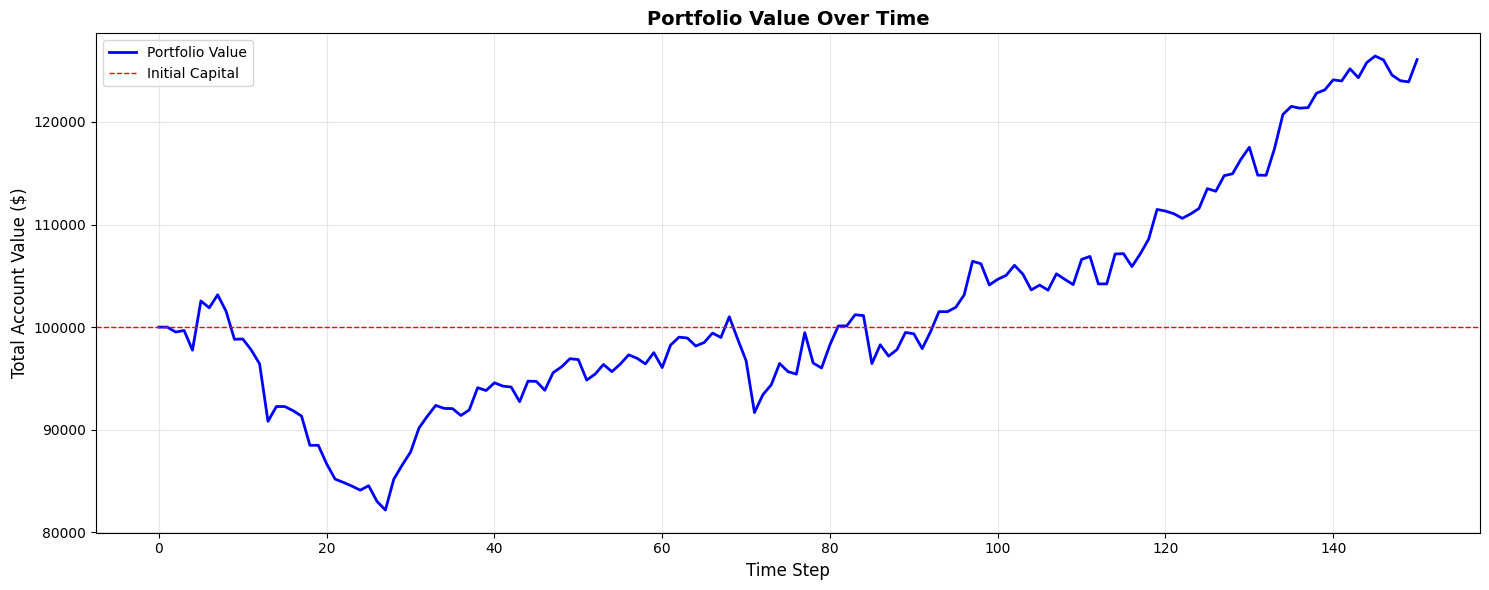

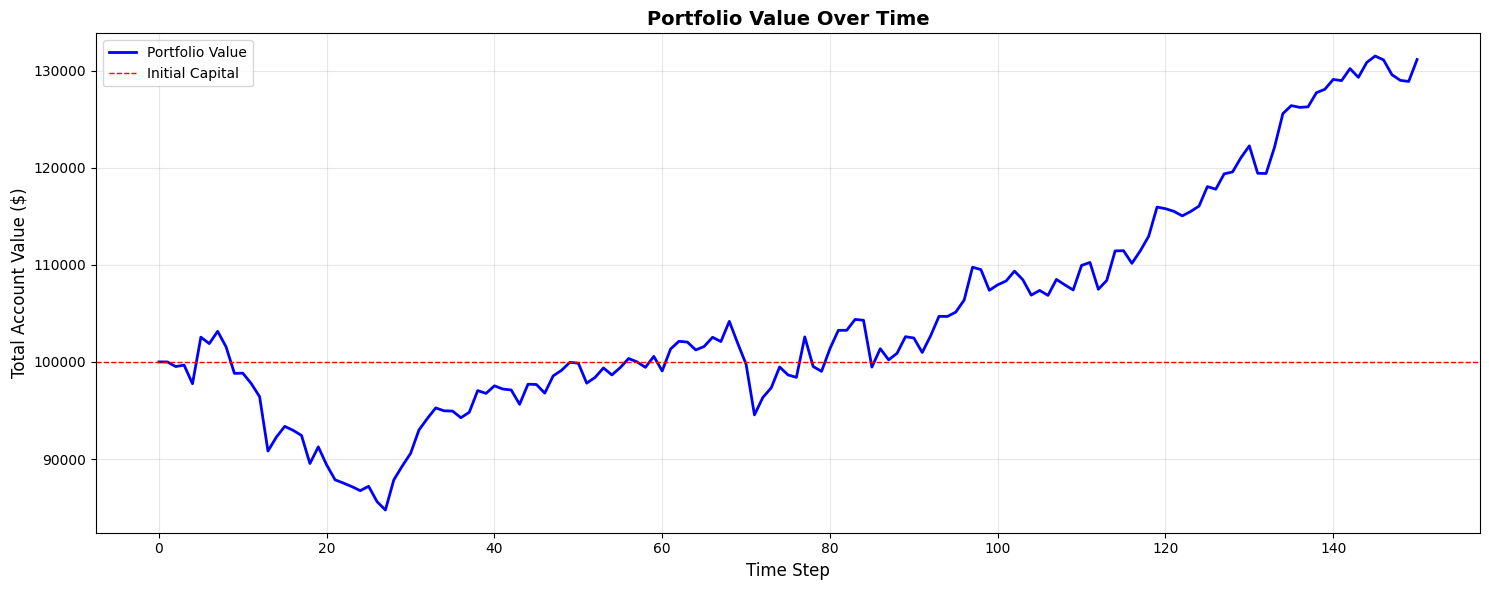

In [43]:
env = StockTradingEnv(file_path="stock_details_5_years_processed.csv",train=True,window_size=50)

pporewards = PPO_StockTrading(env_fn=env, hidden_size=256,n_episodes=300,gamma=0.99,lr=1e-4, file_name="ppo_stock.pth")


#Backtesting PPO

Action: 0 Reward: 0.0 Value: 100000.0
Action: 0 Reward: -0.1 Value: 99655.62036132846
Action: 0 Reward: -0.1 Value: 98237.56829834009
Action: 0 Reward: -0.1 Value: 98642.73785400433
Action: 0 Reward: -0.1 Value: 102100.0661010748
Action: 0 Reward: -0.1 Value: 103990.80218505884
Action: 0 Reward: -0.1 Value: 102484.97924804721
Action: 0 Reward: -0.1 Value: 103342.55572509808
Action: 0 Reward: -0.1 Value: 101802.95486450249
Action: 0 Reward: -0.10789604863096167 Value: 100391.65838623105
Action: 0 Reward: -0.10812140946367076 Value: 101721.91888427759
Action: 0 Reward: -0.10826038317676336 Value: 103153.4821166998
Action: 0 Reward: -0.10772065001012834 Value: 103423.58135986335
Action: 0 Reward: -0.10797077055994715 Value: 105354.83026123105
Action: 0 Reward: -0.1065645691436187 Value: 104780.85385131865
Action: 0 Reward: -0.10639426497269441 Value: 106401.4803466802
Action: 0 Reward: -0.10585847287897213 Value: 107670.97161865259
Action: 0 Reward: -0.10618520235949067 Value: 106691.8463

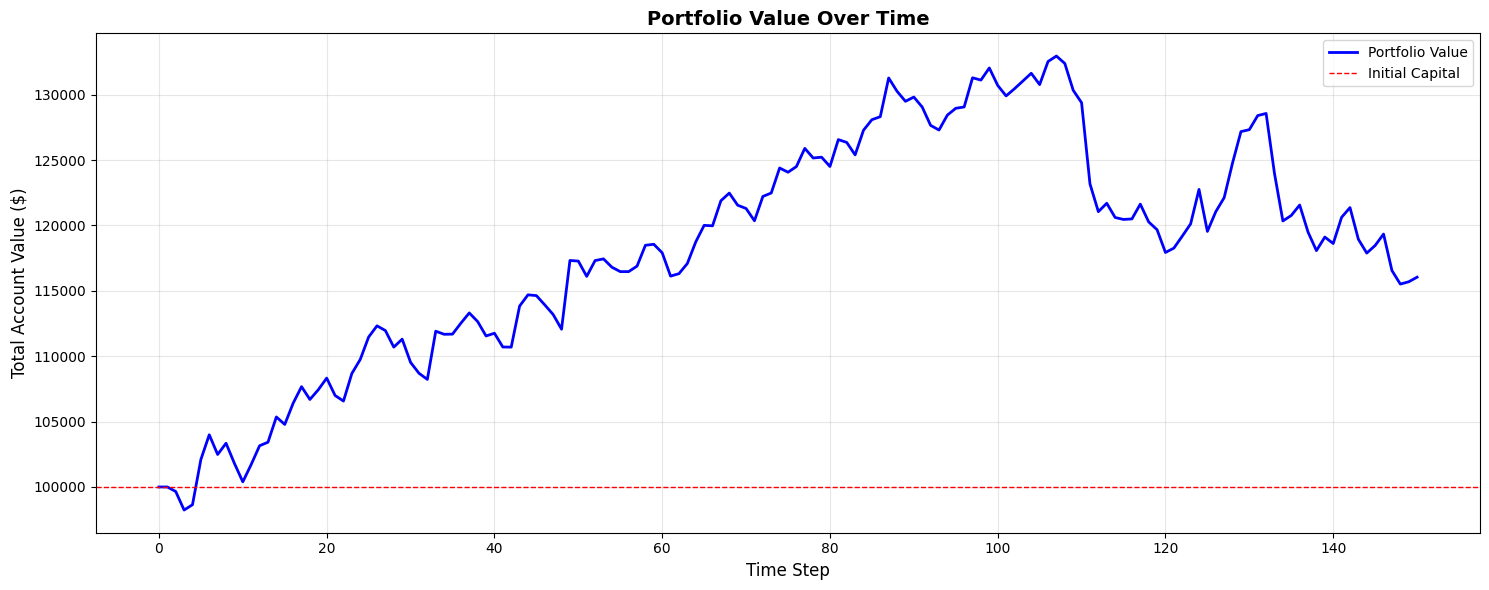

In [45]:
env_test = StockTradingEnv(file_path="stock_details_5_years_processed.csv",train=False,window_size=50)
agent = A2CBacktestAgent(env=env_test,model_path="ppo_stock.pth",hidden_size=256,greedy=True)

obs, info = env_test.reset()
terminated = truncated = False

while not (terminated or truncated):
    action = agent.step(obs)
    obs, reward, terminated, truncated, info = env_test.step(action)
    print("Action:", action, "Reward:", reward, "Value:", info["total_value"])
env_test.render()
